In [9]:
# imports
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
class BaseState(TypedDict):
    weight: float
    height: float
    bmi: float
    categoy: str

In [4]:
def bmi_calculator(state: BaseState) -> BaseState:

    weight = state["weight"]
    height = state["height"]

    bmi = weight / (height**2)

    state["bmi"] = round(bmi, 2)

    return state

In [5]:
def fit_category(state: BaseState) -> BaseState:
    bmi = state["bmi"]

    if bmi < 18.5:
        category = "underweight"
    elif 18.5 <= bmi < 24.9:
        category = "normal"
    elif 25.0 <= bmi < 29.9:
        category = "overweight"
    else:
        category = "obese"

    state["categoy"] = category

    return state

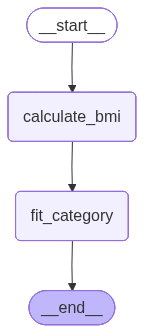

In [6]:
graph = StateGraph(BaseState)

# add node
graph.add_node("calculate_bmi", bmi_calculator)
graph.add_node("fit_category", fit_category)

# add edge
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", "fit_category")
graph.add_edge("fit_category", END)

# compile graph
workflow = graph.compile()

workflow

In [8]:
input_state = {"weight": 82, "height": 1.73}

final_state = workflow.invoke(input_state)
final_state

{'weight': 82, 'height': 1.73, 'bmi': 27.4, 'categoy': 'overweight'}